In [109]:
import math
import pandas as pd
import numpy as np
import seaborn as sns
import string
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split
from TF_IDF_functions import*
from numpy.linalg import norm


In [7]:
dataset = pd.read_csv('../data/horoscope_saved.csv')


# # Merge all tweets by the same user
# user_texts = dataset.groupby('username')['tweet'].agg(lambda x: ' '.join(x)).reset_index()

# # Optional: rename columns for clarity
# user_texts.columns = ['username', 'merged_tweet']
# tweets = user_texts['merged_tweet']




# # Simple preprocessing: lowercase, split by space, discarding mentions and URLs as they are too specific
# docs = []
# clean_tweets = []  
# for tweet in tweets:
#     if not tweet or tweet.strip() == "":
#         continue
#     words = tweet.lower().split()
#     clean_words = [w for w in words if not w.startswith('@') and not w.startswith('http') and not w.startswith('www') ]
#     if clean_words:
#         docs.append(clean_words)
#         clean_tweets.append(tweet)  # keep the original tweet for reference


# Getting the list of words with the lowest TF.IDF to filter it out

translator = str.maketrans('', '', string.punctuation)

predictions = dataset['horoscope']
docs_cleaned = predictions.apply(clean_text)
docs = [pred.lower().split() for pred in docs_cleaned ]


# # Calculate TF (normalized by max frequency in the document)
# tf_list = []
# for doc in docs:
#     counts = Counter(doc)
#     max_count = max(counts.values())
#     tf = {word: count/max_count for word, count in counts.items()}
#     tf_list.append(tf)

# # Calculate IDF (Inverse Document Frequency)
# all_words = set(word for doc in docs for word in doc)

# N = len(docs)
# idf = {}
# for word in all_words:
#     df = sum(1 for doc in docs if word in doc)
#     idf[word] = math.log2(N/df) 

# # Calculate TF-IDF
# tfidf_list = []
# for tf in tf_list:
#     tfidf = {word: tf[word]*idf[word] for word in tf}
#     tfidf_list.append(tfidf)


# top_keywords = sorted(tfidf.items(), key=lambda x: x[1], reverse=False)

# print(top_keywords[:50])




# enlever mots présents une seule fois


FileNotFoundError: [Errno 2] No such file or directory: '../data/horoscope_saved.csv'

## Code for functions

Getting stop_words: threshold for words present in more than ...% of all predictions = "common" words (by the IDF score of these words). Also, suppressing the words only present once, as they cannot be used to gather predictions between them.

## Creating a whitelist for most specific words by categories

We suppress the birthday category from our analysis as it is always the same prediction for the same sign.

In [59]:
dataset = pd.read_csv('../data/horoscope_full.csv')
dataset_filtered = dataset[dataset['category'] != 'birthday'].copy()

categories = dataset_filtered.groupby('category')['horoscope'].agg(lambda x: ' '.join(x)).reset_index()
docs_cleaned = categories['horoscope'].apply(clean_text)
cat_docs = [pred.split() for pred in docs_cleaned ]

cat_tf_idf = getting_tf_idf(cat_docs)

top_keywords_per_cat = []

blacklist = {'she', 'he', 'her','fourweek','workrelated', 'workweek', 'youd', 'todays', 'arrive', 'interesting', 'theyre', 'virgo', 'scorpio', 'cancer', 'libra', 'leo', 'gemini', 'taurus', 'aries', 'pisces', 'capricorn', 'aquarius', 'sagittarius'} 
# supressing the words that are the results of compression, or that are indeed to, common for being whitelisted
# also, we supress the sign which are the most repeated words of the general category. 
# We will anyway take these words with us when creating a whitelist by sign.
target_count = 15

whitelist_cat = []

# Extract top keywords per category
for i, tfidf in enumerate(cat_tf_idf):
    sorted_scores = sorted(tfidf.items(), key=lambda x: x[1], reverse=True)
    final_keywords = []

    for word, score in sorted_scores:

        if word in blacklist:
            continue 
        
        final_keywords.append((word, score))
        
        if len(final_keywords) == target_count:
            break
    
    # Store as a dict with tweet and its top keywords
    top_keywords_per_cat.append({
        'category': categories['category'].iloc[i],
        'top_keywords': [word for word, score in final_keywords],
        'best_TF_IDF': final_keywords[0][1]
    })

#print(top_keywords_per_cat)

whitelist_cat = set(word for category in top_keywords_per_cat for word in category['top_keywords'])

# [{'category': 'career', 'top_keywords': ['workplace', 'relations', 'tremendous', 'major', 'employers', 'coworkers', 'opposition', 'superiors', 'trend', 'jobs', 'concept', 'towel', 'four', 'andor', 'employer'], 'best_TF_IDF': 0.006939488672286022}, 
# {'category': 'general', 'top_keywords': ['virgo', 'scorpio', 'cancer', 'libra', 'leo', 'gemini', 'taurus', 'aries', 'pisces', 'capricorn', 'aquarius', 'sagittarius', 'income', 'visitors', 'youd'], 'best_TF_IDF': 0.049633389734912575}, 
# {'category': 'love', 'top_keywords': ['prospective', 'astral', 'configuration', 'celestial', 'date', 'indicates', 'concerning', 'indicate', 'concerned', 'constellation', 'permanent', 'fascinating', 'yourselves', 'sorted', 'interplay'], 'best_TF_IDF': 0.020040662213186174}, 
# {'category': 'wellness', 'top_keywords': ['transit', 'diet', 'yoga', 'drinking', 'aerobic', 'recommended', 'exercises', 'vegetables', 'bodys', 'digestive', 'wellness', 'lavender', 'liver', 'organs', 'dairy'], 'best_TF_IDF': 0.023549246750421495}]

## Creating a whitelist for most specific words by sign

In [60]:
categories = dataset_filtered.groupby('sign')['horoscope'].agg(lambda x: ' '.join(x)).reset_index()
docs_cleaned = categories['horoscope'].apply(clean_text)
cat_docs = [pred.split() for pred in docs_cleaned ]

cat_tf_idf = getting_tf_idf(cat_docs)

top_keywords_per_sign = []

blacklist = {'prefers', 'isn’t'}
target_count = 11 # the sign name + 10 most specific words

whitelist_sign = []

# Extract top keywords per sign
for i, tfidf in enumerate(cat_tf_idf):
    sorted_scores = sorted(tfidf.items(), key=lambda x: x[1], reverse=True)
    final_keywords = []

    for word, score in sorted_scores:

        if word in blacklist:
            continue 
        
        final_keywords.append((word, score))
        
        if len(final_keywords) == target_count:
            break
    
    # Store as a dict with tweet and its top keywords
    top_keywords_per_sign.append({
        'sign': categories['sign'].iloc[i],
        'top_keywords': [word for word, score in final_keywords],
        'best_TF_IDF': final_keywords[0][1]
    })

# print(top_keywords_per_sign)


whitelist_sign = set(word for sign in top_keywords_per_sign for word in sign['top_keywords'])

final_whitelist = whitelist_cat | whitelist_sign

print(len(whitelist_cat))
print(len(whitelist_sign))
print(len(final_whitelist))

#Total length of white_list: 189 words

# [{'sign': 'aquarius', 'top_keywords': ['aquarius', 'liberate', 'twisted', 'barnacles', 'prefers', 'infinite', 'italian', 'obey', 'plummet', 'crawl', 'puzzling', 'bangs'], 'best_TF_IDF': 0.23276278265551856}, 
# {'sign': 'aries', 'top_keywords': ['aries', 'refurnishing', 'midday', 'creeping', 'reborn', 'redecorating', 'remodeling', 'roiling', 'millionaire', 'sculpting', 'biting'], 'best_TF_IDF': 0.2352046231361471}, 
# {'sign': 'cancer', 'top_keywords': ['cancer', 'mileage', 'responding', 'deliveries', 'freedomloving', 'unreal', 'protest', 'portfolio', 'impatiently', 'vindictive', 'nonexistent'], 'best_TF_IDF': 0.2433454592625667}, 
# {'sign': 'capricorn', 'top_keywords': ['capricorn', 'aloud', 'escapism', 'ray', 'faraway', 'requested', 'salesperson', 'dab', 'restraints', 'constitutes', 'inferno'], 'best_TF_IDF': 0.23550338455029815}, 
# {'sign': 'gemini', 'top_keywords': ['gemini', 'random', 'gray', 'factoriented', 'psychologist', 'rulers', 'strategically', 'rebalancing', 'inherited', 'conventions', 'disappeared'], 'best_TF_IDF': 0.24465621523027387}, 
# {'sign': 'leo', 'top_keywords': ['leo', 'drawers', 'donating', 'earning', 'pigeonholed', 'attribute', 'bucks', 'studious', 'transaction', 'myth', 'tranquil'], 'best_TF_IDF': 0.24266570252815378}, 
# {'sign': 'libra', 'top_keywords': ['libra', 'makeup', 'hardships', 'lily', 'rearing', 'entice', 'distasteful', 'pupils', 'renovation', 'prisoner', 'throwback'], 'best_TF_IDF': 0.23908963478209716}, 
# {'sign': 'pisces', 'top_keywords': ['pisces', 'characters', 'exhibitions', 'stampede', 'frolic', 'palaces', 'timeless', 'messenger', 'storms', 'liberties', 'postcard'], 'best_TF_IDF': 0.2348289390007269}, 
# {'sign': 'sagittarius', 'top_keywords': ['sagittarius', 'outs', 'fidget', 'halftruths', 'braver', 'unplug', 'beckon', 'honeys', 'fallow', 'activating', 'pampered'], 'best_TF_IDF': 0.10607651468241104}, 
# {'sign': 'scorpio', 'top_keywords': ['scorpio', 'isn’t', 'battlefield', 'answering', 'diplomat', 'niggling', 'regretting', 'reassess', 'ramming', 'mischief', 'organizational', 'undermining'], 'best_TF_IDF': 0.24573773506705926}, 
# {'sign': 'taurus', 'top_keywords': ['taurus', 'gateway', 'placid', 'midday', 'declaring', 'reborn', 'rocking', 'strayed', 'widely', 'affirm', 'bar'], 'best_TF_IDF': 0.23465209095629386}, 
# {'sign': 'virgo', 'top_keywords': ['virgo', 'engrossed', 'substantiate', 'comedy', 'scientists', 'escalates', 'stupid', 'indicative', 'giddy', 'substantial', 'hamburger'], 'best_TF_IDF': 0.24588986754751502}]

59
130
189


## Determine the stop word threshlod by an elbow rule

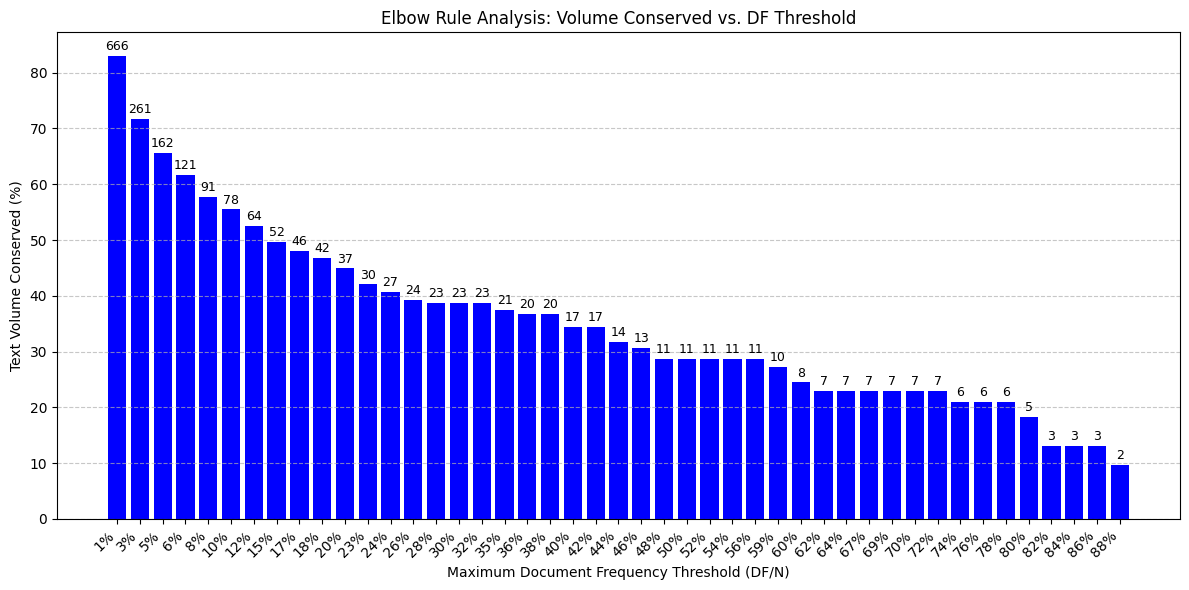

In [61]:
predictions = dataset_filtered['horoscope']
docs_cleaned = predictions.apply(clean_text)
docs = [pred.lower().split() for pred in docs_cleaned ]

total_words_count = 0
for doc in docs:
    for word in doc:
        total_words_count += 1

absence_range = np.arange(0.01, 0.9, 0.02)
remove_percentage = []
nb_swords = []

for threshold in absence_range:

    _, common_stop_words, _, _ = stop_words(docs, threshold, arg_print=False)

    stop_words_occurrences = 0

    for doc in docs:
        for word in doc:
            if word in common_stop_words:
                stop_words_occurrences += 1

    percentage_removed = (stop_words_occurrences / total_words_count) * 100
    remove_percentage.append(percentage_removed)
    nb_swords.append(len(common_stop_words))

# Plot the elbow rule
    
# Convert thresholds to percentage labels for better readability on the X-axis
x_labels = [f'{int(val * 100)}%' for val in absence_range]

fig, ax = plt.subplots(figsize=(12, 6))

# Create the bar plot
bars = ax.bar(x_labels, remove_percentage, color='blue')

# Add annotations (number of stop words removed) on top of each bar
for bar, num_swords in zip(bars, nb_swords):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2., 
            height + 0.5, 
            f'{num_swords}',
            ha='center', 
            va='bottom', 
            fontsize=9)

# Set labels and title
ax.set_xlabel("Maximum Document Frequency Threshold (DF/N)")
ax.set_ylabel("Text Volume Conserved (%)")
ax.set_title("Elbow Rule Analysis: Volume Conserved vs. DF Threshold")
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## Getting all the stop words


In [62]:
predictions = dataset_filtered['horoscope']
docs_cleaned = predictions.apply(clean_text)
docs = [pred.lower().split() for pred in docs_cleaned ]

(idf_pairs_frequent, common_stop_words, idf_pairs_rare, rare_stop_words) = stop_words(docs, 0.10)

sign_names = ['virgo', 'scorpio', 'cancer', 'libra', 'leo', 'gemini', 'taurus', 'aries', 'pisces', 'capricorn', 'aquarius', 'sagittarius']
rescued_keywords = final_whitelist & set(common_stop_words)
final_stop_words = (set(common_stop_words) - final_whitelist) | set(rare_stop_words) | set(sign_names)

print(len(rescued_keywords), " common words rescued from being banned: ", rescued_keywords)
print(len(final_stop_words), " words that will be suppressed from predictions, including the sign names")

Most common words (present in more than 10.0 % of the dataset):
['you', 'to', 'the', 'your', 'and', 'a', 'of', 'is', 'be', 'in', 'that', 'this', 'it', 'will', 'are', 'with', 'for', 'have', 'may', 'today', 'on', 'if', 'or', 'not', 'yourself', 'time', 'can', 'but', "don't", 'as', 'do', 'at', 'get', 'feel', 'more', 'what', 'out', 'take', 'make', 'some', 'could', 'about', 'so', 'need', 'up', 'from', 'day', 'all', 'an', 'there', 'energy', 'way', 'one', 'find', 'people', 'good', 'by', 'work', 'into', 'things', 'than', 'when', 'someone', 'just', 'others', 'go', 'life', 'want', 'something', 'try', 'now', 'them', 'other', 'like', 'new', 'might', "it's", 'planetary', 'very', "today's", 'much', 'love', 'they', 'how', 'been']
Which is a total of 85 words.

Words only present in one prediction over the whole dataset:
['stagnating', 'pushpull', 'tightfisted', 'victimization', 'deplete', 'nightingale', 'default', 'florence', 'sponsor', 'houseguests', 'repairing', 'forged', 'compiling', 'plaid', 'polk

Most common words (present in more than 10.0 % of the dataset):  
['you', 'to', 'the', 'your', 'and', 'a', 'of', 'is', 'be', 'in', 'that', 'this', 'it', 'will', 'are', 'with', 'for', 'have', 'may', 'today', 'on', 'if', 'or', 'not', 'yourself', 'time', 'can', 'but', "don't", 'as', 'do', 'at', 'get', 'feel', 'more', 'what', 'out', 'take', 'make', 'some', 'could', 'about', 'so', 'need', 'up', 'from', 'day', 'all', 'an', 'there', 'energy', 'way', 'one', 'find', 'people', 'good', 'by', 'work', 'into', 'things', 'than', 'when', 'someone', 'just', 'others', 'go', 'life', 'want', 'something', 'try', 'now', 'them', 'other', 'like', 'new', 'might', "it's", 'planetary', 'very', "today's", 'much', 'love', 'they', 'how', 'been']  

Which is a total of 85 words.

0  words rescued from being banned:  set()

85  words that will be suppressed from predictions

Maybe determine the threshold with an elbow rule ? 

## Stop words statistics

In [63]:
total_words_count = 0
common_stop_words_occurrences = 0
stop_words_occurrences = 0

for doc in docs:
    for word in doc:
        total_words_count += 1
        if word in common_stop_words:
            common_stop_words_occurrences += 1
        if word in final_stop_words:
            stop_words_occurrences += 1

percentage_removed_common = (common_stop_words_occurrences / total_words_count) * 100
percentage_removed_tot = (stop_words_occurrences / total_words_count) * 100

print("Total number of words in all predictions: ", total_words_count)
print("Total occurences of common stop words: ",  common_stop_words_occurrences, ", which represents ", percentage_removed_common, "%.")
print("Total occurences of all stop words: ",  stop_words_occurrences, ", which represents ", percentage_removed_tot, "%.")

Total number of words in all predictions:  1138336
Total occurences of common stop words:  646187 , which represents  56.76592851319822 %.
Total occurences of all stop words:  653518 , which represents  57.40993871756669 %.


## Rewriting all predictions in the dataset, without the stop words

In [64]:
final_dataset = dataset_filtered.copy()
final_dataset['horoscope_cleaned'] = final_dataset['horoscope'].apply(lambda x: final_prediction_cleaner(x, final_stop_words))


print("\nPrediction example (Original vs. Cleaned):")
print(f"Original: {final_dataset['horoscope'].iloc[0]}")
print(f"Cleaned:  {final_dataset['horoscope_cleaned'].iloc[0]}")




Prediction example (Original vs. Cleaned):
Original: There's a great day ahead of you, Aries. You'll be blessed with the ability to solve problems, and others will come looking for you today. You'll listen, understand, and express empathy. You'll be wise enough to find solutions to any issues they present to you. After a day like this, you might ask yourself if you shouldn't work as a therapist.
Cleaned:  there's great ahead you'll blessed ability solve problems come looking you'll listen understand express empathy you'll wise enough solutions any issues present after ask shouldn't therapist


In [65]:
# file_path = '../data/horoscope_cleaned_final.csv'

# final_dataset.to_csv(file_path, index=False, encoding='utf-8')

# df_swords = pd.DataFrame(final_stop_words, columns=['Stop_word'])
# file_path2 = '../data/stop_words_list.csv'
# df_swords.to_csv(file_path2, index=False, encoding='utf-8')



## Final dataset stats

In [66]:
final_word_count = 0

for pred in final_dataset['horoscope_cleaned']:
    words_in_current_prediction = pred.split()
    
    final_word_count += len(words_in_current_prediction)

print("Words in the new predictions: ", final_word_count)
print("Added to the count of stop_words", stop_words_occurrences + final_word_count)
print("Is the old total: ", total_words_count, " the same as this number: ", (stop_words_occurrences + final_word_count), "?")



Words in the new predictions:  484818
Added to the count of stop_words 1138336
Is the old total:  1138336  the same as this number:  1138336 ?


# Predicting an horoscope category with TF-IDF vector space similarity

Plan: 
- Taking the clean dataset (or original one)  
- Group by category, sign or both, and separate into modeling set and testing set (80/20)  
- Compute classic TF.IDF on concatenated chosen categories  
- Compute TF for each predictions of the testing dataset, then merge with a vocab-sized vector to have a TF vector with all words from the dataset in it (mostly 0s)
- Multiply it by IDF from grouped categories (IDF depends only on the corpus and is common for all files within it) ==> Each prediction from testing dataset has a TF.IDF vector in the same vector space as the grouped category
- Compute the cosine similarity between each prediction and vectors from general category
- Predicts category based on the closest distance
- Compute confusion matrix to visualize results

In [67]:
test_size = 0.2
random_state = 42

categories = 'sign'

data_model, data_test = train_test_split(
    final_dataset, test_size=test_size, random_state=random_state, stratify=final_dataset[categories])

print(data_model.shape, data_test.shape)

subsets = data_model.groupby(categories)['horoscope_cleaned'].agg(lambda x: ' '.join(x)).reset_index()



(14053, 6) (3514, 6)


### Working by group to create the model vectors

In [ ]:
subsets_cleaned = subsets['horoscope_cleaned'].apply(clean_text)
subsets_docs = [pred.split() for pred in subsets_cleaned]


group_tf_idf_vect = getting_tf_idf(subsets_docs)

# print(len(group_tf_idf_vect[0]))


for i, tfidf in enumerate(group_tf_idf_vect):
    group_tf_idf_vect[i] = {categories: subsets[categories].iloc[i],
                       "tf.idf_vector": tfidf}

print(group_tf_idf_vect[0])


group_idf_dict = getting_idf(subsets_docs) #will be used later for computing the testing predictions' TD.IDF



{'strong': 0.0, 'disciplinary': 0.010782057828035076, 'socializing': 0.002561854736405282, 'pleasant': 0.0, 'thoroughly': 0.0017893496995496174, 'comparison': 0.00859207078798499, 'matter': 0.0, 'involved': 0.0, 'economized': 0.02156411565607015, 'preparation': 0.0, 'mention': 0.0008539515788017607, 'discussed': 0.011938010218799104, "they're": 0.0, 'purposeful': 0.006802721088435374, 'speaks': 0.006802721088435374, 'wacky': 0.01758477891647045, 'strengths': 0.0008539515788017607, 'tension': 0.0, 'deserves': 0.005368049098648853, 'moves': 0.0, 'jest': 0.013605442176870748, 'testosterone': 0.010782057828035076, 'knowitall': 0.00859207078798499, 'dead': 0.0028233843488356717, 'inspiring': 0.005646768697671343, 'box': 0.0028233843488356717, 'example': 0.0, 'rampant': 0.01758477891647045, 'patterns': 0.0, 'reckless': 0.0008539515788017607, 'intentions': 0.0, 'put': 0.0, 'selfknowledge': 0.0017893496995496174, 'long': 0.0, 'experiences': 0.005977661051612324, 'probe': 0.010579694947803428, 

### Working on test predictions to create a vector of same dimension

In [ ]:
predictions = data_test.copy()
predictions['horoscope_cleaned'] = predictions['horoscope_cleaned'].apply(clean_text)

predictions['sliced'] = [pred.split() for pred in predictions['horoscope_cleaned']]

preds_tf = getting_tf(predictions['sliced'])

preds_tf_idf = []
for i in range(len(predictions)): 
    tfidf = {word: preds_tf[i].get(word, 0)*group_idf_dict[word] for word in group_idf_dict}
    preds_tf_idf.append({'ID': predictions['ID'].iloc[i], 
                        'true_cat': predictions[categories].iloc[i],
                       "tf.idf_vector": tfidf})
    
print(len(preds_tf_idf[0]["tf.idf_vector"])) #same length as the vector from grouped categories



10757


### Rearranging vectors in alphabetic order

In [ ]:
vocabulary = sorted(group_idf_dict.keys()) # get a list of words ordered 

#ordering the references according to the vocabulary

for cat in group_tf_idf_vect:
    cat['cosine_vect'] = np.array([cat["tf.idf_vector"][word] for word in vocabulary])

for pred in preds_tf_idf:
    pred['cosine_vect'] = np.array([pred["tf.idf_vector"][word] for word in vocabulary])





### Cosine similarity within categories

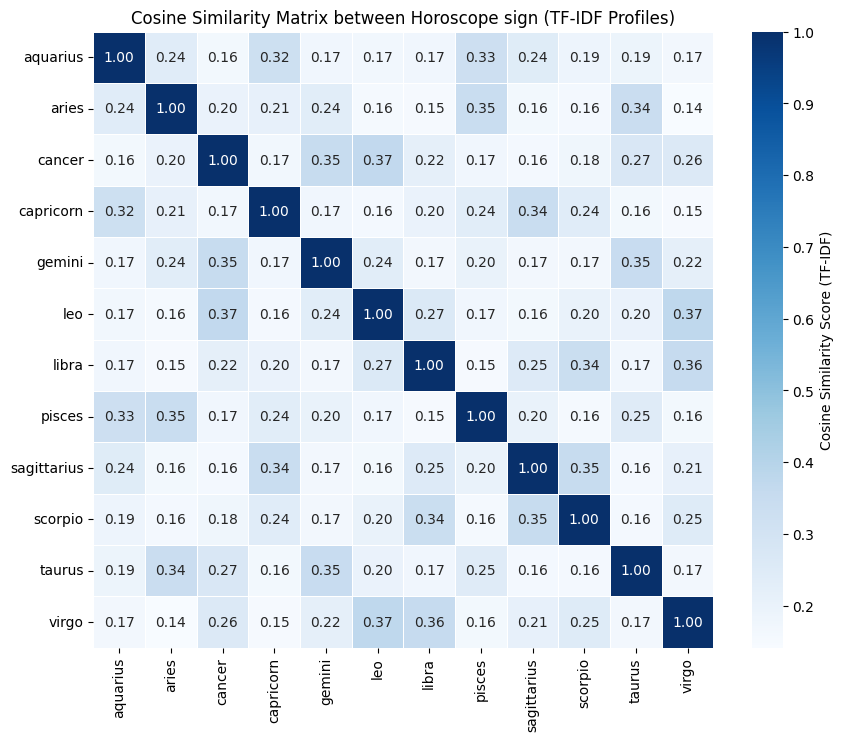

In [122]:
cat_similarity = []

for cat1 in group_tf_idf_vect:
    for cat2 in group_tf_idf_vect:
        cat_similarity.append(cosine_similarity(cat1['cosine_vect'], cat2['cosine_vect']))


cat_names = [cat[categories] for cat in group_tf_idf_vect]

n_cat = len(cat_names)
similarity_matrix = np.array(cat_similarity).reshape(n_cat, n_cat)

similarity_df = pd.DataFrame(similarity_matrix, index=cat_names, columns=cat_names)

plt.figure(figsize=(10, 8))


sns.heatmap(
    similarity_df,
    annot=True,            
    fmt=".2f",               
    cmap="Blues",           
    linewidths=.5,           
    cbar_kws={'label': 'Cosine Similarity Score (TF-IDF)'} 
)

plt.title(f'Cosine Similarity Matrix between Horoscope {categories} (TF-IDF Profiles)')
plt.show()

### Cosine similarity for each prediction to the model ones

In [127]:
prediction_matrix = np.zeros((n_cat, n_cat))
prediction_df = pd.DataFrame(prediction_matrix, index=cat_names, columns=cat_names)

for pred in preds_tf_idf:
    similarity = predict_cat(group_tf_idf_vect, pred['cosine_vect'], categories)
    cat_predicted = similarity[0]
    true_cat = pred[categories]
    prediction_df.loc[true_cat, cat_predicted] += 1


plt.figure(figsize=(10, 8))


sns.heatmap(
    prediction_df,
    annot=True,            
    fmt="d",               
    cmap="viridis",           
    linewidths=.5,   
    cbar=False        
) 
plt.ylabel('True labels') # Ajout d'étiquettes
plt.xlabel('Predicted Labels')
plt.title(f'Confusion Matrix TF.IDF per {categories}')
plt.show()

KeyError: 'sign'

In [125]:
def predict_cat(cat_dict, test_vector, categories): 

    max_similarity = -1.0
    predicted_cat = None

    for cat in cat_dict:
        ref_cat = cat[categories]
        ref_vector = cat['cosine_vect']

        similarity = cosine_similarity(ref_vector, test_vector)

        if similarity > max_similarity:
            max_similarity = similarity
            predicted_cat = ref_cat

    return predicted_cat, max_similarity